In [13]:
from pathlib import Path

import pandas as pd

# Notebook en Clustering 2/ → dataset en documentation/
BASE_DIR = Path(".").resolve()
DATASET_PATH = BASE_DIR / "documentation" / "gaming_users_raw.csv"

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"No se encontró el dataset: {DATASET_PATH}")

df = pd.read_csv(DATASET_PATH, encoding="utf-8")

for col in ("fecha_registro", "fecha_ultima_sesion"):
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(f"Dataset cargado: {DATASET_PATH.name}")
print(f"Filas: {len(df):,}  |  Columnas: {df.shape[1]}")
df.head()

Dataset cargado: gaming_users_raw.csv
Filas: 8,080  |  Columnas: 36


,user_id,fecha_registro,dias_desde_registro,fecha_ultima_sesion,dias_inactivo,plataforma,pais,version_app,modelo_dispositivo_tier,ram_gb,...,genero_favorito,amigos_count,pertenece_guild,mensajes_chat_semana,partidas_coop_semana,retencion_d1,retencion_d7,retencion_d30,crash_rate_pct,latencia_ms_promedio
0,USR-000001,2026-05-29,2,2026-05-29,2.0,android,CL,3.2,medio,6.3,...,accion,108.0,True,171.0,42.36,True,True,NaN,1.90,105.1
1,USR-000002,2025-07-14,321,2026-05-26,5.0,ios,MX,3.2,bajo,4.0,...,rpg,26.0,True,7.0,4.04,False,False,NaN,2.25,144.0
2,USR-000003,2024-06-29,701,2026-01-18,133.0,ios,MX,2.8,medio,4.1,...,puzzle,7.0,False,0.0,0.00,False,False,NaN,2.02,82.0
3,USR-000004,2026-03-18,74,2026-05-27,4.0,ios,MX,3.1,alto,10.6,...,estrategia,41.0,True,21.0,11.95,True,False,NaN,0.49,94.8
4,USR-000005,2026-04-25,36,2026-05-20,11.0,ios,BR,3.1,bajo,2.7,...,estrategia,6.0,False,3.0,0.40,True,True,True,4.50,158.5


## Variables para clustering y perfilamiento

Selección según `documentation/04-notas-clustering.md` y perfiles latentes del plan (`casual`, `core`, `grinder`, `whale`, `social`, `churn_risk`, …).

**Incluidas:** engagement, monetización, progresión, social, retención, dispositivo y contexto codificable.

**Excluidas:** metadatos (`user_id`, fechas crudas), `tienda_principal` (muchos nulos MAR), `ticket_promedio_mxn` / `gasto_mensual_promedio` (inestables), `xp_total` (redundante con `nivel_jugador`).

In [14]:
import numpy as np

# --- Selección alineada al plan (04-notas-clustering.md) ---
CLUSTER_BLOCKS = {
    "engagement": [
        "sesiones_semanales",
        "minutos_juego_dia",
        "streak_dias",
        "partidas_por_sesion",
    ],
    "monetizacion": [
        "gasto_total_mxn",
        "compras_in_app_count",
        "es_pagador",
    ],
    "progresion": [
        "nivel_jugador",
        "misiones_completadas",
    ],
    "social": [
        "amigos_count",
        "mensajes_chat_semana",
        "partidas_coop_semana",
        "pertenece_guild",
    ],
    "retencion": [
        "dias_desde_registro",
        "dias_inactivo",
        "retencion_d1",
        "retencion_d7",
        "retencion_d30",
    ],
    "dispositivo": [
        "modelo_dispositivo_tier",
        "ram_gb",
        "crash_rate_pct",
        "latencia_ms_promedio",
    ],
    "contexto": [
        "plataforma",
        "genero_favorito",
        "pais",
    ],
}

CLUSTER_COLS = [col for cols in CLUSTER_BLOCKS.values() for col in cols]

pd.DataFrame(
    {"columna": CLUSTER_COLS, "bloque": [b for b, cols in CLUSTER_BLOCKS.items() for _ in cols]}
).groupby("bloque")["columna"].apply(list).to_frame("variables")

,variables
bloque,
contexto,"[plataforma, genero_favorito, pais]"
dispositivo,"[modelo_dispositivo_tier, ram_gb, crash_rate_p..."
engagement,"[sesiones_semanales, minutos_juego_dia, streak..."
monetizacion,"[gasto_total_mxn, compras_in_app_count, es_pag..."
progresion,"[nivel_jugador, misiones_completadas]"
retencion,"[dias_desde_registro, dias_inactivo, retencion..."
social,"[amigos_count, mensajes_chat_semana, partidas_..."


In [15]:
from IPython.display import display

BOOL_COLS = [
    "es_pagador",
    "pertenece_guild",
    "retencion_d1",
    "retencion_d7",
    "retencion_d30",
]

def to_bool_numeric(series: pd.Series) -> pd.Series:
    """Convierte bool/object a 0/1; NaN -> 0 (cuenta sin señal)."""
    if series.dtype == bool or str(series.dtype) == "boolean":
        return series.astype("Int64").fillna(0).astype(float)
    mapped = series.astype(str).str.strip().str.lower().map(
        {"true": 1, "false": 0, "1": 1, "0": 0, "1.0": 1, "0.0": 0}
    )
    return mapped.fillna(0).astype(float)

# Matriz de perfilamiento: user_id + señales de segmentación
df_cluster = df[["user_id", *CLUSTER_COLS]].copy()

# --- Limpieza mínima (04-notas-clustering.md §3.2) ---
df_cluster["plataforma"] = (
    df_cluster["plataforma"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"android": "android", "ios": "ios"})
)
df_cluster["genero_favorito"] = df_cluster["genero_favorito"].astype(str).str.strip().str.lower()
df_cluster["modelo_dispositivo_tier"] = (
    df_cluster["modelo_dispositivo_tier"].astype(str).str.strip().str.lower()
)
df_cluster["minutos_juego_dia"] = df_cluster["minutos_juego_dia"].clip(0, 1440)

for col in BOOL_COLS:
    if col in df_cluster.columns:
        df_cluster[col] = to_bool_numeric(df_cluster[col])

# retencion_d30: MAR estructural (cuentas < 30 días) -> 0
if "retencion_d30" in df_cluster.columns:
    joven = df_cluster["dias_desde_registro"] < 30
    df_cluster.loc[joven, "retencion_d30"] = df_cluster.loc[joven, "retencion_d30"].fillna(0)

# Ordinal: tier de dispositivo
tier_map = {"bajo": 0, "medio": 1, "alto": 2}
df_cluster["tier_ordinal"] = df_cluster["modelo_dispositivo_tier"].map(tier_map)

# Top países + "otro" (frequency encoding simplificado)
df_cluster["pais"] = df_cluster["pais"].fillna("otro")
top_paises = df_cluster["pais"].value_counts().head(8).index
df_cluster["pais_top"] = df_cluster["pais"].where(df_cluster["pais"].isin(top_paises), "otro")
pais_freq = df_cluster["pais_top"].value_counts(normalize=True)
df_cluster["pais_freq"] = df_cluster["pais_top"].map(pais_freq)

# One-hot: plataforma y género favorito (solo android/ios tras limpieza)
df_cluster = pd.get_dummies(
    df_cluster,
    columns=["plataforma", "genero_favorito"],
    prefix=["plat", "gen"],
    dtype=int,
)

DROP_FOR_X = {
    "user_id",
    "modelo_dispositivo_tier",
    "pais",
    "pais_top",
}
FEATURE_COLS = [c for c in df_cluster.columns if c not in DROP_FOR_X]

X_profile = df_cluster[FEATURE_COLS].copy()

# Imputación: mediana en numéricas; 0 en bool y fallback final
for col in X_profile.columns:
    if col in BOOL_COLS or X_profile[col].dtype == bool or str(X_profile[col].dtype) == "boolean":
        X_profile[col] = to_bool_numeric(X_profile[col])
    elif pd.api.types.is_numeric_dtype(X_profile[col]):
        med = X_profile[col].median()
        X_profile[col] = X_profile[col].fillna(0 if pd.isna(med) else med)

X_profile = X_profile.fillna(0)

LOG1P_COLS = ["gasto_total_mxn", "compras_in_app_count", "mensajes_chat_semana", "misiones_completadas"]
for col in LOG1P_COLS:
    if col in X_profile.columns:
        X_profile[col] = np.log1p(X_profile[col].clip(lower=0))

nulos_restantes = int(X_profile.isna().sum().sum())
assert nulos_restantes == 0, f"Quedan {nulos_restantes} NaN en X_profile; revisar limpieza."

print(f"Usuarios: {len(df_cluster):,}")
print(f"Variables para clustering: {len(FEATURE_COLS)}")
print(f"NaN en X_profile: {nulos_restantes}")
display(pd.DataFrame({"variable": FEATURE_COLS}))
df_cluster.head()

Usuarios: 8,080
Variables para clustering: 30
NaN en X_profile: 0


,variable
0,sesiones_semanales
1,minutos_juego_dia
2,streak_dias
3,partidas_por_sesion
4,gasto_total_mxn
5,compras_in_app_count
6,es_pagador
7,nivel_jugador
8,misiones_completadas
9,amigos_count


,user_id,sesiones_semanales,minutos_juego_dia,streak_dias,partidas_por_sesion,gasto_total_mxn,compras_in_app_count,es_pagador,nivel_jugador,misiones_completadas,...,tier_ordinal,pais_top,pais_freq,plat_android,plat_ios,gen_accion,gen_casual,gen_estrategia,gen_puzzle,gen_rpg
0,USR-000001,3.74,9.37,12.0,0.53,0.76,1.0,1.0,3.0,15.0,...,1.0,CL,0.062624,1,0,1,0,0,0,0
1,USR-000002,7.33,16.14,20.0,1.05,2.89,1.0,1.0,6.0,150.0,...,0.0,MX,0.320297,0,1,0,0,0,0,1
2,USR-000003,0.26,2.00,0.0,0.26,0.00,0.0,0.0,2.0,12.0,...,1.0,MX,0.320297,0,1,0,0,0,1,0
3,USR-000004,5.14,14.11,30.0,0.73,411.95,19.0,1.0,3.0,72.0,...,2.0,MX,0.320297,0,1,0,0,1,0,0
4,USR-000005,6.00,7.58,1.0,0.86,0.00,0.0,0.0,2.0,15.0,...,0.0,BR,0.091955,0,1,0,0,1,0,0


In [16]:
df.shape

(8080, 36)

- El análisis de componentes principales (PCA, por sus siglas en inglés) es una técnica estadística utilizada para reducir la dimensión de conjuntos de datos con muchas variables, manteniendo la mayor cantidad posible de información original. El objetivo principal es identificar y construir nuevas variables, llamadas componentes principales, que son combinaciones lineales de las variables originales.

- Los componentes principales se calculan de tal manera que:
  - El primer componente principal captura la mayor varianza posible de los datos.
  - El segundo componente es ortogonal al primero y captura la mayor varianza posible restante, y así sucesivamente.
  - Cada componente es una combinación de todas las variables originales pero con diferentes pesos (coeficientes), dependiendo de cómo contribuyen a la variabilidad global del conjunto de datos.

- Ejemplo de cómo un componente representa varias variables en una ecuación:
  - Supongamos que tenemos tres variables originales: X1 (horas de juego), X2 (compras dentro de la app) y X3 (número de partidas semanales).
  - El primer componente principal (PC1) podría representarse así:
    - PC1 = 0.6 × X1 + 0.3 × X2 + 0.7 × X3
  - En esta ecuación, los coeficientes (0.6, 0.3, 0.7) reflejan la importancia relativa de cada variable en el componente. Los valores de estos coeficientes se determinan a partir de los datos para 
  maximizar la varianza explicada.

- Ejemplo sencillo representativo:
  - Si tomamos tres usuarios con datos en las tres variables anteriores:
    - Usuario A: X1 = 10, X2 = 5, X3 = 14
    - Usuario B: X1 = 4, X2 = 0, X3 = 8
    - Usuario C: X1 = 7, X2 = 3, X3 = 10
  - Calculando PC1 para el Usuario A:
    - PC1_A = 0.6*10 + 0.3*5 + 0.7*14 = 6 + 1.5 + 9.8 = 17.3
  - Así, un solo valor (el componente principal) resume la información de estas tres variables para cada usuario.

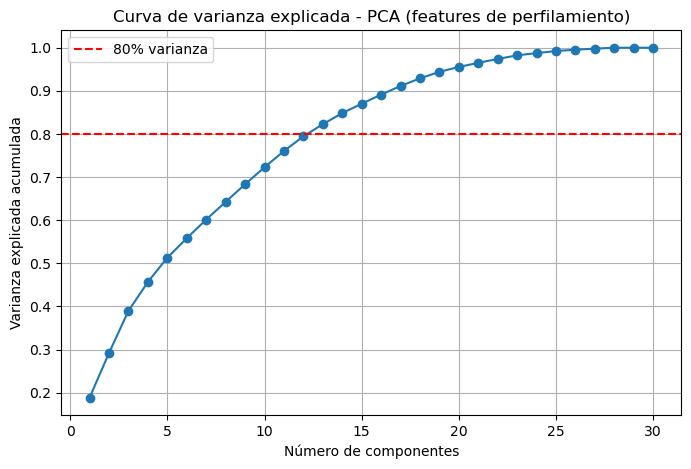

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Matriz de clustering (variables del plan, ya imputadas y con log1p)
X = X_profile.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

varianza_explicada_acum = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_explicada_acum) + 1), varianza_explicada_acum, marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Curva de varianza explicada - PCA (features de perfilamiento)")
plt.grid(True)
plt.axhline(y=0.80, color="r", linestyle="--", label="80% varianza")
plt.legend()
plt.show()

In [18]:
# Exporta un scatterplot 3D interactivo de los cinco primeros componentes principales usando plotly
import plotly.graph_objs as go
import plotly.io as pio
import numpy as np

# Extrae los cinco primeros componentes principales
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]
pc3 = X_pca[:, 2]
pc4 = X_pca[:, 3]
pc5 = X_pca[:, 4]

# Normaliza PC4 para tono y PC5 para brillo
norm_pc4 = (pc4 - np.min(pc4)) / (np.max(pc4) - np.min(pc4) + 1e-9)
norm_pc5 = (pc5 - np.min(pc5)) / (np.max(pc5) - np.min(pc5) + 1e-9)

# Construye colores HSV y convierte a RGB
import colorsys
rgb_colors = [colorsys.hsv_to_rgb(h, 0.75, v) for h, v in zip(norm_pc4, norm_pc5)]
# Convierte a hex para plotly
def rgb_to_hex(rgb):
    return '#%02x%02x%02x' % tuple(int(255*x) for x in rgb)
hex_colors = [rgb_to_hex(rgb) for rgb in rgb_colors]

trace = go.Scatter3d(
    x=pc1,
    y=pc2,
    z=pc3,
    mode='markers',
    marker=dict(
        size=4,
        color=hex_colors,
    ),
    text=[f'PC4: {c4:.2f}<br>PC5: {c5:.2f}' for c4, c5 in zip(pc4, pc5)],
)

layout = go.Layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3',
    ),
    title='PCA: 5 componentes (x=PC1, y=PC2, z=PC3, color=PC4, brillo=PC5)',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig = go.Figure(data=[trace], layout=layout)

# Exporta el gráfico a HTML interactivo (no muestra en notebook)
pio.write_html(fig, file="pca_scatter_5components.html", auto_open=False)

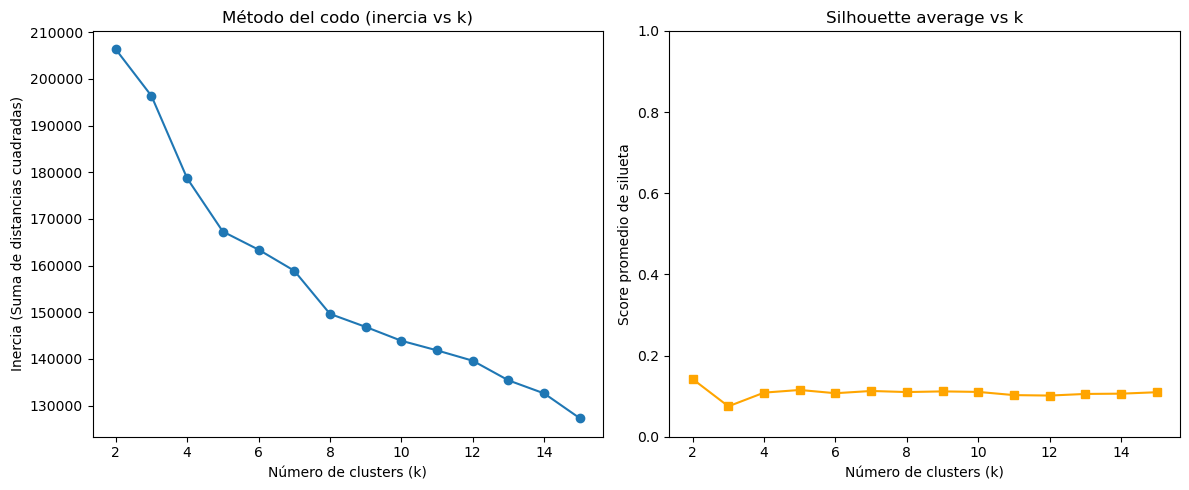

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Usamos X_pca o X_std según correspondan las features para clustering. Aquí, X_pca (PCs).
k_range = range(2, 16)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(k_range, inertias, marker='o')
ax[0].set_title('Método del codo (inercia vs k)')
ax[0].set_xlabel('Número de clusters (k)')
ax[0].set_ylabel('Inercia (Suma de distancias cuadradas)')

ax[1].plot(k_range, silhouette_scores, marker='s', color='orange')
ax[1].set_title('Silhouette average vs k')
ax[1].set_xlabel('Número de clusters (k)')
ax[1].set_ylabel('Score promedio de silueta')
ax[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

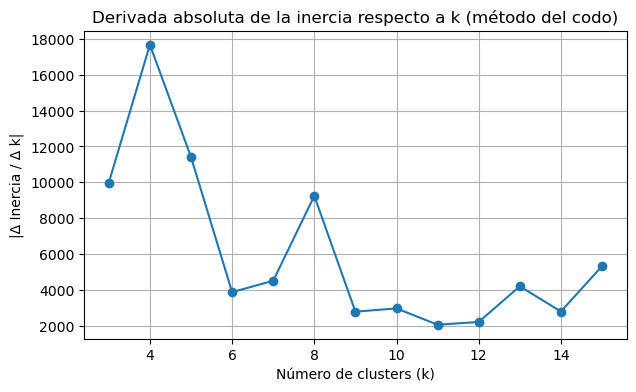

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Calcula la derivada numérica absoluta (dif1) de la inercia respecto a k
inertias = np.array(inertias)
k_array = np.array(list(k_range))
d_inercia = np.abs(np.diff(inertias) / np.diff(k_array))

# Graficar la derivada absoluta del método del codo
plt.figure(figsize=(7, 4))
plt.plot(k_array[1:], d_inercia, marker='o')
plt.title('Derivada absoluta de la inercia respecto a k (método del codo)')
plt.xlabel('Número de clusters (k)')
plt.ylabel('|Δ Inercia / Δ k|')
plt.grid(True)
plt.show()

Init: k-means++  | Inertia: 176759.35 | Silhouette: 0.1409
Init: random     | Inertia: 176759.25 | Silhouette: 0.1410


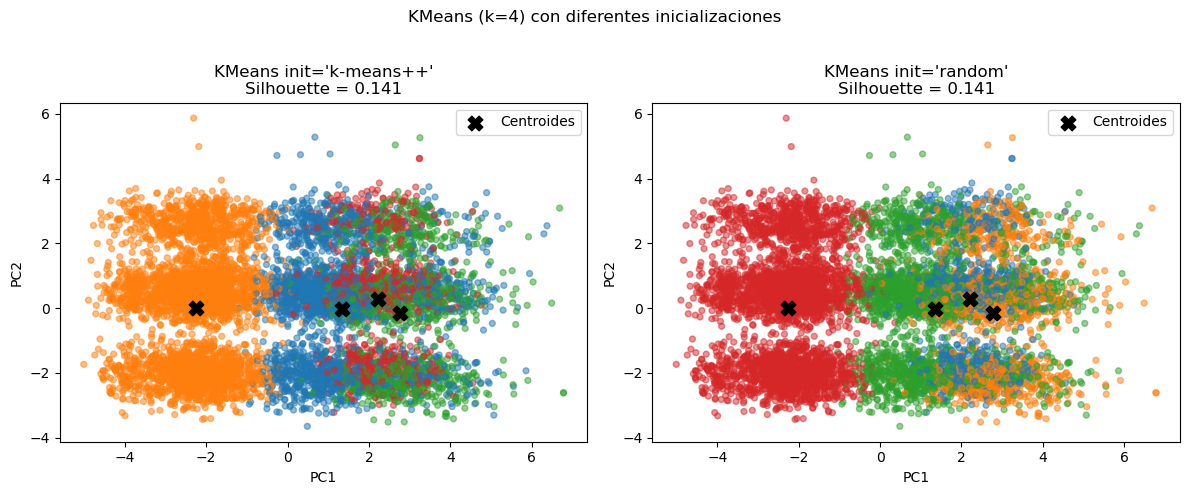

In [22]:
# Aplicar KMeans con k=4 y buscar una buena init (comparar 'k-means++' y 'random')
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Probar diferentes métodos de inicialización
inits = ['k-means++', 'random']
results = {}

for init in inits:
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=20, init=init)
    labels = kmeans.fit_predict(X_pca)
    inertia = kmeans.inertia_
    sil_score = silhouette_score(X_pca, labels)
    results[init] = {
        'labels': labels,
        'inertia': inertia,
        'silhouette': sil_score,
        'centers': kmeans.cluster_centers_
    }
    print(f"Init: {init:10s} | Inertia: {inertia:.2f} | Silhouette: {sil_score:.4f}")

# Gráfica de clusters en 2 primeras componentes principales para ambas inits
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
colors = np.array(['C0', 'C1', 'C2', 'C3'])

for i, init in enumerate(inits):
    ax = axs[i]
    labels = results[init]['labels']
    centers = results[init]['centers']
    # Graficar puntos
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors[labels], alpha=0.5, s=18)
    # Graficar centroides
    ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=110, label='Centroides')
    ax.set_title(f"KMeans init='{init}'\nSilhouette = {results[init]['silhouette']:.3f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()

plt.suptitle("KMeans (k=4) con diferentes inicializaciones")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

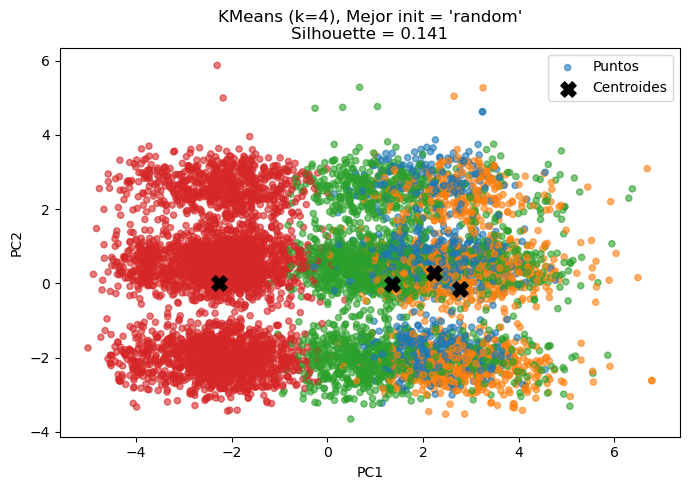

In [23]:
# Obtener el mejor 'init' según mayor silhouette_score
best_init = max(results, key=lambda x: results[x]['silhouette'])
best_labels = results[best_init]['labels']
best_centers = results[best_init]['centers']
best_sil = results[best_init]['silhouette']

plt.figure(figsize=(7, 5))
colors = np.array(['C0', 'C1', 'C2', 'C3'])
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors[best_labels], alpha=0.6, s=20, label="Puntos")
plt.scatter(best_centers[:, 0], best_centers[:, 1], c='black', marker='X', s=120, label="Centroides")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans (k=4), Mejor init = '{best_init}'\nSilhouette = {best_sil:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
import plotly.express as px
import plotly.io as pio

# Visualización 3D con plotly de los 4 clusters en componentes principales
fig_3d = px.scatter_3d(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    z=X_pca[:, 2],
    color=best_labels.astype(str),
    labels={"x": "PC1", "y": "PC2", "z": "PC3", "color": "Cluster"},
    opacity=0.55,
    title="Clusters KMeans (k=4) - Proyección 3D PCA"
)

# Añadir centroides al 3D
centroids_3d = best_centers[:, :3]
fig_3d.add_scatter3d(
    x=centroids_3d[:, 0],
    y=centroids_3d[:, 1],
    z=centroids_3d[:, 2],
    mode="markers",
    marker=dict(size=12, color="black", symbol="x"),
    name="Centroides"
)

# Exportar como HTML
pio.write_html(fig_3d, file="plotly_kmeans_3d_clusters.html", auto_open=False)


In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import plotly.express as px
import plotly.io as pio

# KNN para predecir el cluster en el espacio PCA 3D
knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean', algorithm='auto', n_jobs=-1)  # Fijamos random_state usando n_jobs + 'kd_tree'
knn.fit(X_pca[:, :3], best_labels)
knn_pred = knn.predict(X_pca[:, :3])

# Matriz de confusión y accuracy
cm_knn = confusion_matrix(best_labels, knn_pred)
acc_knn = accuracy_score(best_labels, knn_pred)

print("Matriz de confusión KNN vs Cluster KMeans:\n", cm_knn)
print(f"Exactitud KNN para predecir cluster de KMeans: {acc_knn:.4f}")

# Visualización 3D con Plotly: clusters predichos por KNN en el espacio PCA
fig_knn_3d = px.scatter_3d(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    z=X_pca[:, 2],
    color=knn_pred.astype(str),
    labels={"x": "PC1", "y": "PC2", "z": "PC3", "color": "Cluster (KNN)"},
    opacity=0.45,
    title=f"KNN (k=7) - Clusters predichos en PCA3D<br>Accuracy={acc_knn:.3f}"
)

# Añadimos los centroides originales para referencia
fig_knn_3d.add_scatter3d(
    x=best_centers[:, 0],
    y=best_centers[:, 1],
    z=best_centers[:, 2],
    mode="markers",
    marker=dict(size=12, color="black", symbol="x"),
    name="Centroides"
)

# Exportar a HTML
pio.write_html(fig_knn_3d, file="plotly_knn_3d_clusters.html", auto_open=False)

Matriz de confusión KNN vs Cluster KMeans:
 [[ 883    0   36    0]
 [   0 1215   32    0]
 [  35   14 2110   23]
 [   0    2   45 3685]]
Exactitud KNN para predecir cluster de KMeans: 0.9769


## Agglomerative vs KNN — lectura correcta

- **KNN no clusteriza**: replica las etiquetas de **K-Means** en el espacio PCA (~97% accuracy). Por eso “se ve mejor”: está copiando K-Means, no descubriendo segmentos nuevos.
- **Silhouette alto ≠ buen segmento**: `linkage='average'` con `k=4` puede dejar **un cluster con ~99%** de usuarios (silueta inflada, perfil inútil).
- **Criterio aquí**: solo configuraciones con clusters **balanceados** (mín. 3% del total) y `linkage='ward'` sobre `X_scaled` o PCs que acumulen ≥80% varianza.

In [34]:
import numpy as np
import pandas as pd
from IPython.display import display
import plotly.express as px
import plotly.io as pio
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

MIN_CLUSTER_FRAC = 0.03  # descartar particiones degeneradas (ej. 99% en un solo cluster)

pca_var_cum = pca.explained_variance_ratio_.cumsum()
n_pca_80 = int(np.searchsorted(pca_var_cum, 0.80) + 1)

SEARCH_SPACES = {
    "X_scaled": X_scaled,
    f"X_pca[:{n_pca_80}]": X_pca[:, :n_pca_80],
}

k_range = range(6, 9)  # rango de negocio gaming (~7 perfiles latentes)
linkages = ["ward", "average", "complete"]

rows = []
for space_name, X_space in SEARCH_SPACES.items():
    n = len(X_space)
    min_size = int(MIN_CLUSTER_FRAC * n)
    for linkage in linkages:
        for k in k_range:
            if linkage == "ward":
                model = AgglomerativeClustering(n_clusters=k, linkage="ward")
            else:
                model = AgglomerativeClustering(
                    n_clusters=k, linkage=linkage, metric="euclidean"
                )
            labels = model.fit_predict(X_space)
            counts = np.bincount(labels)
            if counts.min() < min_size:
                continue
            sil = silhouette_score(X_space, labels)
            ari = adjusted_rand_score(best_labels, labels)
            rows.append({
                "space": space_name,
                "linkage": linkage,
                "n_clusters": k,
                "silhouette": sil,
                "ari_vs_kmeans": ari,
                "min_cluster": int(counts.min()),
                "max_cluster": int(counts.max()),
            })

if not rows:
    raise ValueError("Ninguna config pasó el filtro de balance; baja MIN_CLUSTER_FRAC o amplía k_range.")

df_agglo_grid = pd.DataFrame(rows).sort_values(
    ["silhouette", "ari_vs_kmeans"], ascending=False
)
best_row = df_agglo_grid.iloc[0]
best_space = best_row["space"]
best_linkage = best_row["linkage"]
best_k = int(best_row["n_clusters"])
X_agglo = SEARCH_SPACES[best_space]

print(f"Configs válidas (cluster mín. ≥ {MIN_CLUSTER_FRAC:.0%}): {len(df_agglo_grid)}")
display(df_agglo_grid.head())

if best_linkage == "ward":
    agglo = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
else:
    agglo = AgglomerativeClustering(
        n_clusters=best_k, linkage=best_linkage, metric="euclidean"
    )

agglo_labels = agglo.fit_predict(X_agglo)
sil_agglo = silhouette_score(X_agglo, agglo_labels)
ari_agglo = adjusted_rand_score(best_labels, agglo_labels)

print(
    f"\nMejor config: space={best_space}, linkage='{best_linkage}', k={best_k}"
)
print(f"Silhouette: {sil_agglo:.4f}  |  ARI vs K-Means: {ari_agglo:.4f}")
print(f"Referencia K-Means silhouette: {best_sil:.4f}")
print("(KNN ~97% accuracy solo indica que imita bien K-Means, no que clusterice mejor.)")
print("\nDistribución de clusters (Agglomerative):")
print(pd.Series(agglo_labels).value_counts().sort_index())

fig_agglo_3d = px.scatter_3d(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    z=X_pca[:, 2],
    color=agglo_labels.astype(str),
    labels={"x": "PC1", "y": "PC2", "z": "PC3", "color": "Cluster (Agglo)"},
    opacity=0.45,
    title=(
        f"Agglomerative — {best_space}, {best_linkage}, k={best_k}<br>"
        f"Silhouette={sil_agglo:.3f} | ARI vs KMeans={ari_agglo:.3f}"
    ),
)

html_path = "plotly_agglomerative_3d_clusters.html"
pio.write_html(fig_agglo_3d, file=html_path, auto_open=False)
print(f"\nHTML exportado: {html_path}")
fig_agglo_3d.show()


Top 5 configuraciones (submuestra n=2000):


,linkage,n_clusters,silhouette
7,average,4,0.401873
8,average,5,0.372684
9,average,6,0.310684
0,ward,4,0.194870
14,complete,4,0.181391



Mejor config: linkage='average', n_clusters=4 | Silhouette (full): 0.3975
Referencia K-Means silhouette: 0.1410

Distribución de clusters (Agglomerative):
0    8017
1      11
2       2
3      50
Name: count, dtype: int64

HTML exportado: plotly_agglomerative_3d_clusters.html


In [42]:
from sklearn.cluster import DBSCAN
import plotly.express as px
import plotly.io as pio

# DBSCAN: ¿el eps está bajito o bien? 
# Puedes ajustar eps (prueba subirlo un poco si ves todo como ruido, o bájalo si todos quedan en 1 cluster grande)
dbscan = DBSCAN(
    eps=2.5,         
    min_samples=25,   
    metric='euclidean'
)
dbscan_labels = dbscan.fit_predict(X_agglo)

# Distribución de etiquetas DBSCAN (-1 = ruido)
print('\nDistribución de clusters (DBSCAN):')
print(pd.Series(dbscan_labels).value_counts().sort_index())

# Gráfica 3D con clusters de DBSCAN y exporta a HTML
fig_dbscan_3d = px.scatter_3d(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    z=X_pca[:, 2],
    color=dbscan_labels.astype(str),
    labels={"x": "PC1", "y": "PC2", "z": "PC3", "color": "DBSCAN cluster"},
    opacity=0.6,
    title=f"DBSCAN (eps={dbscan.eps}, min_samples={dbscan.min_samples}) — clusters: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}, ruido: {(dbscan_labels == -1).sum()}"
)
dbscan_html_path = "plotly_dbscan_3d_clusters.html"
pio.write_html(fig_dbscan_3d, file=dbscan_html_path, auto_open=False)
print(f"HTML exportado: {dbscan_html_path}")


Distribución de clusters (DBSCAN):
-1     6434
 0      501
 1      548
 2      138
 3       53
 4       33
 5      121
 6       61
 7       68
 8       81
 9       25
 10      17
Name: count, dtype: int64
HTML exportado: plotly_dbscan_3d_clusters.html


## DBSCAN como detector de anomalías

En clustering por **densidad**, los puntos que no pertenecen a ningún cluster reciben etiqueta **`-1` (ruido)** → candidatos a **anomalía**.

| Parámetro | Rol |
|-----------|-----|
| `eps` | Radio de vecindad: menor → más puntos aislados (más anomalías) |
| `min_samples` | Mínimo de vecinos para ser núcleo denso |

**Criterio de ajuste (plan):** fracción de ruido cercana a ~3.5% (`p_anomaly` + duplicados), no el silhouette máximo.

**Variables de perfil:** sesiones, gasto, inactividad, nivel — para describir el comportamiento atípico detectado.

In [45]:
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display
import plotly.express as px
import plotly.io as pio
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

pca_var_cum = pca.explained_variance_ratio_.cumsum()
n_pca_80 = int(np.searchsorted(pca_var_cum, 0.80) + 1)
X_anomaly = X_pca[:, :n_pca_80]

TARGET_NOISE_FRAC = 0.035
MIN_SAMPLES = 20

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, metric="euclidean")
nn.fit(X_anomaly)
k_dist = np.sort(nn.kneighbors(X_anomaly)[0][:, -1])
eps_grid = np.unique(
    np.round(np.percentile(k_dist, [70, 75, 80, 85, 88, 90, 92, 94, 95, 96, 97, 98]), 3)
)

tune_rows = []
for eps in eps_grid:
    labels = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, metric="euclidean").fit_predict(X_anomaly)
    n_anom = int((labels == -1).sum())
    noise_frac = n_anom / len(labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    tune_rows.append({
        "eps": eps,
        "n_anomalias": n_anom,
        "noise_frac": noise_frac,
        "n_clusters_densos": n_clusters,
        "dist_to_target": abs(noise_frac - TARGET_NOISE_FRAC),
    })

df_dbscan_tune = pd.DataFrame(tune_rows).sort_values("dist_to_target")
best_eps = float(df_dbscan_tune.iloc[0]["eps"])

print(f"Espacio: PCA {n_pca_80} comps | min_samples={MIN_SAMPLES} | objetivo ruido={TARGET_NOISE_FRAC:.1%}")
display(df_dbscan_tune.head(8))

dbscan_anom = DBSCAN(eps=best_eps, min_samples=MIN_SAMPLES, metric="euclidean")
dbscan_anom_labels = dbscan_anom.fit_predict(X_anomaly)
is_anomaly = dbscan_anom_labels == -1

print(
    f"eps={best_eps} → {is_anomaly.sum():,} anomalías ({is_anomaly.mean():.2%}) | "
    f"clusters densos: {len(set(dbscan_anom_labels)) - 1}"
)

PROFILE_VARS = [
    "sesiones_semanales", "minutos_juego_dia", "gasto_total_mxn",
    "dias_inactivo", "nivel_jugador", "amigos_count", "compras_in_app_count",
]
available = [c for c in PROFILE_VARS if c in df_cluster.columns]
df_anom_profile = df_cluster[["user_id", *available]].copy()
df_anom_profile["anomalia_dbscan"] = is_anomaly

display(
    df_anom_profile.groupby("anomalia_dbscan")[available]
    .median()
    .rename(index={False: "normal", True: "anomalía"})
)

prof_path = Path("documentation/gaming_users_raw_professor.csv")
if prof_path.exists():
    eval_df = df_anom_profile.merge(
        pd.read_csv(prof_path)[["user_id", "flag_anomalia", "tipos_anomalia"]], on="user_id"
    )
    tp = (eval_df["anomalia_dbscan"] & eval_df["flag_anomalia"]).sum()
    fp = (eval_df["anomalia_dbscan"] & ~eval_df["flag_anomalia"]).sum()
    fn = (~eval_df["anomalia_dbscan"] & eval_df["flag_anomalia"]).sum()
    print(f"[Docente] Precision={tp/(tp+fp):.3f} Recall={tp/(tp+fn):.3f} (TP={tp} FP={fp} FN={fn})")

point_class = np.where(is_anomaly, "anomalía", "normal")
fig_anom_3d = px.scatter_3d(
    x=X_pca[:, 0], y=X_pca[:, 1], z=X_pca[:, 2], color=point_class,
    labels={"x": "PC1", "y": "PC2", "z": "PC3", "color": "Clase"},
    opacity=0.5, color_discrete_map={"normal": "#636efa", "anomalía": "#ef553b"},
    title=f"DBSCAN anomalías — eps={best_eps} | {is_anomaly.sum():,} puntos ({is_anomaly.mean():.2%})",
)
html_path = "plotly_dbscan_anomalies_3d.html"
pio.write_html(fig_anom_3d, file=html_path, auto_open=False)
print(f"HTML exportado: {html_path}")


Espacio: PCA 13 comps | min_samples=20 | objetivo ruido=3.5%


,eps,n_anomalias,noise_frac,n_clusters_densos,dist_to_target
4,3.231,249,0.030817,5,0.004183
3,3.109,322,0.039851,8,0.004851
5,3.339,188,0.023267,4,0.011733
6,3.459,141,0.017450,2,0.017550
2,2.941,433,0.053589,12,0.018589
7,3.605,75,0.009282,1,0.025718
8,3.684,57,0.007054,1,0.027946
9,3.761,42,0.005198,1,0.029802


eps=3.231 → 249 anomalías (3.08%) | clusters densos: 5


,sesiones_semanales,minutos_juego_dia,gasto_total_mxn,dias_inactivo,nivel_jugador,amigos_count,compras_in_app_count
anomalia_dbscan,,,,,,,
normal,5.220,10.67,0.50,6.0,4.0,13.0,0.0
anomalía,9.635,25.12,2.32,3.0,9.0,39.0,1.0


[Docente] Precision=0.205 Recall=0.182 (TP=51 FP=198 FN=229)
HTML exportado: plotly_dbscan_anomalies_3d.html



Barrido de eps para DBSCAN:
    eps  n_clusters  n_noise  silhouette
0   0.5           0     8080         NaN
1   1.0           0     8080         NaN
2   1.5           0     8080         NaN
3   2.0           6     7893   -0.196599
4   2.5          11     6434   -0.186644
5   3.0           9     3738   -0.021403
6   3.5           9     1744   -0.018083
7   4.0           1      451         NaN
8   4.5           1      136         NaN
9   5.0           1       93         NaN
10  5.5           1       88         NaN
11  6.0           1       79         NaN

Mejor eps según silhouette: 3.5


C:\Users\HISC\AppData\Local\Temp\ipykernel_53064\784387049.py:55: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



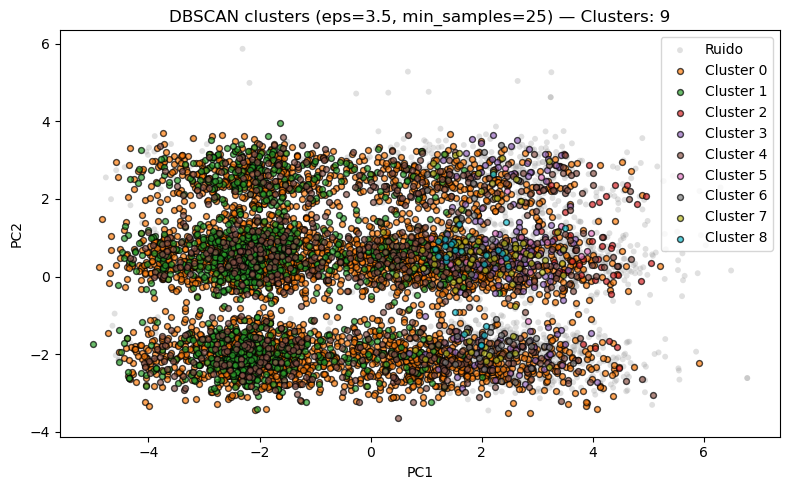

In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score

# Barrido de valores de eps para DBSCAN, usando los datos sin condensar
eps_values = np.arange(0.5, 6.5, 0.5)
min_samples = 25
dbscan_results = []

for eps in eps_values:
    dbscan_tmp = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels_tmp = dbscan_tmp.fit_predict(X_agglo)  # Usar datos originales, no reducidos
    n_clusters = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    n_noise = np.sum(labels_tmp == -1)
    # Calcular silhouette solo si hay más de 1 cluster y menos que samples
    if n_clusters > 1 and n_clusters < len(X_agglo):
        silhouette = silhouette_score(X_agglo, labels_tmp, metric='euclidean')
    else:
        silhouette = np.nan
    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'silhouette': silhouette
    })

# Mostrar tabla de resultados
import pandas as pd
dbscan_results_df = pd.DataFrame(dbscan_results)
print("\nBarrido de eps para DBSCAN:")
print(dbscan_results_df)

# Elegir el mejor eps (máximo silhouette válido, mínimo 2 clusters)
dbscan_results_valid = dbscan_results_df.dropna(subset=["silhouette"])
if not dbscan_results_valid.empty:
    best_dbscan_idx = dbscan_results_valid["silhouette"].idxmax()
    best_eps = dbscan_results_df.loc[best_dbscan_idx, "eps"]
    print(f"\nMejor eps según silhouette: {best_eps}")
else:
    best_eps = eps_values[0]
    print(f"\nNo hay eps con silhouette válida, usando eps={best_eps}")

# Reajustar DBSCAN con el eps óptimo para visualización
dbscan_final = DBSCAN(eps=best_eps, min_samples=min_samples, metric='euclidean')
dbscan_labels_final = dbscan_final.fit_predict(X_agglo)

# Visualización 2D con PCA para ver los clusters DBSCAN óptimos
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_dbscan = PCA(n_components=2, random_state=42)
X_dbscan_pca = pca_dbscan.fit_transform(X_agglo)

plt.figure(figsize=(8, 5))
unique_labels = np.unique(dbscan_labels_final)
colors = [plt.cm.get_cmap('tab10')(i) if lbl != -1 else (0.6,0.6,0.6,0.4) for i, lbl in enumerate(unique_labels)]
for lbl, col in zip(unique_labels, colors):
    mask = dbscan_labels_final == lbl
    plt.scatter(
        X_dbscan_pca[mask, 0],
        X_dbscan_pca[mask, 1],
        s=18,
        color=col,
        label=f'Cluster {lbl}' if lbl != -1 else 'Ruido',
        alpha=0.7 if lbl != -1 else 0.3,
        edgecolor='k' if lbl != -1 else 'none'
    )
plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN clusters (eps={best_eps}, min_samples={min_samples}) — Clusters: {len(unique_labels) - (1 if -1 in unique_labels else 0)}')
plt.tight_layout()
plt.show()